<a href="https://colab.research.google.com/github/mairafaq08/assessment/blob/main/model_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import preprocessing
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
! git config --global user.name "mairafaq08" # replace with your username that you used to create the Github account
! git config --global user.email "afaqmaira05@gmail.com" # and the email id which you have used to create account

In [3]:
username = "mairafaq08" #replace with your own user name
repo = "assessment" #replace with your required repo

In [4]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'assessment'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 5.24 MiB | 5.93 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [5]:
%cd {repo}
%ls

/content/assessment
Assesment_File.ipynb
model_train.ipynb
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [6]:
# Defining datasets based on regions/sites
urban_files = ['PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']
suburban_files = ['PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv']

def load_and_tag(files, region_name):
    dataframes = []
    for f in files:
        temp_df = pd.read_csv(f)
        temp_df['region'] = region_name
        dataframes.append(temp_df)
    return pd.concat(dataframes)

# Combine all into one master dataframe
df_urban = load_and_tag(urban_files, 'Urban')
df_suburban = load_and_tag(suburban_files, 'Sub-urban')
full_df = pd.concat([df_urban, df_suburban])

# Create a proper datetime object
full_df['datetime'] = pd.to_datetime(full_df[['year', 'month', 'day', 'hour']])

print("Data loaded and categorized by region.")
display(full_df.groupby('region').size())
full_df

Data loaded and categorized by region.


,0
region,
Sub-urban,70128
Urban,70128


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,region,datetime
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,Urban,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,Urban,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,Urban,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,Urban,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,Urban,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou,Sub-urban,2017-02-28 19:00:00
35060,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou,Sub-urban,2017-02-28 20:00:00
35061,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou,Sub-urban,2017-02-28 21:00:00
35062,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou,Sub-urban,2017-02-28 22:00:00


In [7]:
## Data Types & Column description ##
#full_df.info()
# ─── Column Descriptions ───────────────────────────────────────────
COL_DESC = {
    "No"          : "Original row index",
    "year"        : "Year of measurement",
    "month"       : "Month of measurement (1–12)",
    "day"         : "Day of month",
    "hour"        : "Hour of day (0–23)",
    "PM2.5"       : "Fine particulates <2.5 μm  (μg/m³)",
    "PM10"        : "Coarse particulates <10 μm  (μg/m³)",
    "SO2"         : "Sulfur dioxide concentration (μg/m³)",
    "NO2"         : "Nitrogen dioxide concentration (μg/m³)",
    "CO"          : "Carbon monoxide concentration (μg/m³)",
    "O3"          : "Ozone concentration (μg/m³)",
    "TEMP"        : "Ambient temperature (°C)",
    "PRES"        : "Atmospheric pressure (hPa)",
    "DEWP"        : "Dew point temperature (°C)",
    "RAIN"        : "Precipitation (mm)",
    "wd"          : "Wind direction (compass direction, categorical)",
    "WSPM"        : "Wind speed (m/s)",
    "station"     : "Monitoring station name",
    "datetime"    : "Timestamp (date + hour, derived)",
    "region"      : "Urban or Suburban classification (derived)",
}
print(f"{'Column':<15}  {'Description'}")
print("-" * 70)
for col in full_df.columns:
    print(f"  {col:<15}  {COL_DESC.get(col, 'N/A')}")

Column           Description
----------------------------------------------------------------------
  No               Original row index
  year             Year of measurement
  month            Month of measurement (1–12)
  day              Day of month
  hour             Hour of day (0–23)
  PM2.5            Fine particulates <2.5 μm  (μg/m³)
  PM10             Coarse particulates <10 μm  (μg/m³)
  SO2              Sulfur dioxide concentration (μg/m³)
  NO2              Nitrogen dioxide concentration (μg/m³)
  CO               Carbon monoxide concentration (μg/m³)
  O3               Ozone concentration (μg/m³)
  TEMP             Ambient temperature (°C)
  PRES             Atmospheric pressure (hPa)
  DEWP             Dew point temperature (°C)
  RAIN             Precipitation (mm)
  wd               Wind direction (compass direction, categorical)
  WSPM             Wind speed (m/s)
  station          Monitoring station name
  region           Urban or Suburban classification (derive

In [8]:
stations = full_df['station'].value_counts()
print(f'Total number of Stations in the dataset : {len(stations)}')
stations

Total number of Stations in the dataset : 4


,count
station,
Dongsi,35064
Wanshouxigong,35064
Dingling,35064
Huairou,35064


In [9]:
## ----------------- Statistical Summary of Data set ------------------##
##full_df.head()
#full_df['year'].unique() ## all months

## yearly data based on months
full_df.groupby(['year', 'month','station'], as_index=True).first(2)
## some of the months are missing in some years

# ─── Statistical Summary ───────────────────────────────────────────
NUM_COLS = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]
NUM_COLS = [c for c in NUM_COLS if c in full_df.columns]

summary = full_df[NUM_COLS].describe().T
summary["skewness"] = full_df[NUM_COLS].skew().round(2)
summary["kurtosis"] = full_df[NUM_COLS].kurt().round(2)
print("Statistical Summary of Numerical Variables:")
print(summary.round(2).to_string())

Statistical Summary of Numerical Variables:
          count     mean      std     min     25%     50%      75%      max  skewness  kurtosis
PM2.5  137078.0    76.72    79.87    2.00    18.0    52.0   107.00    999.0      2.06      6.29
PM10   137786.0    99.48    90.89    2.00    32.0    76.0   139.00    993.0      1.98      6.79
SO2    137214.0    14.90    20.81    0.29     2.0     7.0    18.00    411.0      3.09     14.55
NO2    135028.0    42.37    33.38    1.03    16.0    34.0    61.00    258.0      1.21      1.59
CO     132328.0  1155.98  1082.57  100.00   500.0   800.0  1500.00  10000.0      2.64     10.49
O3     136149.0    60.44    56.12    0.21    16.0    50.0    85.00   1071.0      2.04     14.40
TEMP   140113.0    13.40    11.50  -19.90     3.0    14.4    23.18     41.4     -0.12     -1.13
PRES   140114.0  1009.86    10.51  982.40  1001.3  1009.4  1018.00   1042.0      0.12     -0.81
DEWP   140111.0     2.22    13.85  -43.40    -9.3     2.7    14.90     29.1     -0.17     -1

In [10]:
####  ----------------  checking Missing values ------------------------------- ##

def missing_values_table(full_df):
    # Total missing values
    mis_val = full_df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(full_df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(full_df)
display(missing_values.style.background_gradient(cmap='Blues'))

## CO has most missing values

,Missing Values,% of Total Values
CO,7928,5.652521
NO2,5228,3.727470
O3,4107,2.928217
PM2.5,3178,2.265857
SO2,3042,2.168891
PM10,2470,1.761065
wd,599,0.427076
DEWP,145,0.103382
RAIN,145,0.103382
TEMP,143,0.101956


In [11]:
## Replacing missing values

# PM10 and NH3 are seasonal and city-specific
# So we use median grouped by City + Month as the primary fill
# We add fallbacks for cities where entire months or entire series are missing

# ------------------------------------------------------------------
# LAMBDA EXPLANATION:
# lambda x: x.fillna(x.median())
#
# lambda = a small unnamed function, same as writing:
#   def fill_with_median(x):
#       return x.fillna(x.median())
#
# Here x is one group (e.g. all PM10 rows for Delhi in January)
# x.median() = median value of that group
# x.fillna(...) = fill NaN values with that median
# transform() applies this function to each group and returns
# result in the same shape as the original dataframe
# ------------------------------------------------------------------
# List of all pollutant columns you want to impute
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
mets = ['RAIN', 'TEMP', 'WSPM', 'PRES' , 'DEWP']
for col in pollutants:
    # Fill missing values with the mean of the same station and month
    full_df[col] = full_df.groupby(['station', 'month'])[col].transform(lambda x: x.fillna(x.mean()))

print("PM10 nulls:", full_df['PM10'].isna().sum())
print("PM2.5 nulls:", full_df['PM2.5'].isna().sum())
print("SO2 nulls:", full_df['SO2'].isna().sum())
print("NO2 nulls:", full_df['NO2'].isna().sum())
print("CO nulls:", full_df['CO'].isna().sum())
print("O3 nulls:", full_df['O3'].isna().sum())


for cols in mets:
    # Fill missing values with the mean of the same station and month
    full_df[cols] = full_df.groupby(['station', 'month'])[cols].transform(lambda x: x.fillna(x.mean()))

print("RAIN nulls:", full_df['RAIN'].isna().sum())
print("TEMP nulls:", full_df['TEMP'].isna().sum())
print("WSPM nulls:", full_df['WSPM'].isna().sum())
print("PRES nulls:", full_df['PRES'].isna().sum())
print("DEWP nulls:", full_df['DEWP'].isna().sum())

PM10 nulls: 0
PM2.5 nulls: 0
SO2 nulls: 0
NO2 nulls: 0
CO nulls: 0
O3 nulls: 0
RAIN nulls: 0
TEMP nulls: 0
WSPM nulls: 0
PRES nulls: 0
DEWP nulls: 0


In [12]:
#checking Missing values again
def missing_values_table(full_df):
    # Total missing values
    mis_val = full_df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(full_df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(full_df)
display(missing_values.style.background_gradient(cmap='Blues'))


,Missing Values,% of Total Values
wd,599,0.427076
No,0,0.000000
month,0,0.000000
year,0,0.000000
day,0,0.000000
hour,0,0.000000
PM10,0,0.000000
PM2.5,0,0.000000
NO2,0,0.000000
CO,0,0.000000


In [13]:
full_df = full_df.drop(columns=['wd'])

In [14]:
# CO changes very slowly and has only 7% missing
# Forward fill = carry the last known value forward to fill the gap
# bfill() = backward fill, handles gaps at the very start of a city's series

# ------------------------------------------------------------------
# LAMBDA EXPLANATION:
# lambda x: x.ffill().bfill()
#
# Same as writing:
#   def forward_backward_fill(x):
#       return x.ffill().bfill()
#
# x = all CO rows for one city in date order
# x.ffill() = fills each NaN with the value from the row above it
# .bfill() = chained after ffill, fills any remaining NaN
#            (only at the start of series) with the value below it
# ------------------------------------------------------------------

full_df['RAIN'] = full_df.groupby('station')['RAIN'].transform(
    lambda x: x.ffill().bfill()
)

# Fallback: global median if entire city has no CO data
full_df['RAIN'] = full_df['RAIN'].fillna(full_df['RAIN'].median())

print("RAIN nulls:", full_df['RAIN'].isna().sum())

RAIN nulls: 0


In [15]:
#def missing_values_table(full_df):
    # Total missing values
 #   mis_val = full_df.isnull().sum()

    # Percentage of missing values
 #   mis_val_percent = 100 * mis_val / len(full_df)

  #  mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

  #  mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
  #  mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

  #  return mis_val_table

#missing_values = missing_values_table(full_df)
#display(missing_values.style.background_gradient(cmap='Greens'))

In [16]:
full_df = full_df.dropna(subset=['RAIN'])

In [17]:
## Missing values per station
missing_values_per_station = full_df.groupby('station').apply(lambda x: x.isnull().sum())
print("Total missing values per Station:")
print(full_df.groupby('station').apply(lambda x: x.isnull().sum().sum()))

Total missing values per Station:
station
Dingling         0
Dongsi           0
Huairou          0
Wanshouxigong    0
dtype: int64


In [18]:
# Datetime components -- Calculating day in week and time of the day
# Note: Year, month ,day, Hour columns are already available in the dataset. No need to derive from datetime

## Day of the Week

full_df["day_of_week"] = full_df["datetime"].dt.dayofweek   # 0=Mon
full_df["day_name"]    = full_df["datetime"].dt.day_name()
full_df["is_weekend"]  = full_df["day_of_week"].isin([5, 6]).astype(int)
print("   ✅ Datetime components: hour, day, month, year, day_of_week, is_weekend")
#full_df.head()

# Time of day
def time_of_day(h):
    if   6  <= h < 12: return "Morning"
    elif 12 <= h < 18: return "Afternoon"
    elif 18 <= h < 22: return "Evening"
    else:              return "Night"

full_df["time_of_day"] = full_df["hour"].apply(time_of_day)
print("   ✅ time_of_day added (Morning/Afternoon/Evening/Night)")
full_df

   ✅ Datetime components: hour, day, month, year, day_of_week, is_weekend
   ✅ time_of_day added (Morning/Afternoon/Evening/Night)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,DEWP,RAIN,WSPM,station,region,datetime,day_of_week,day_name,is_weekend,time_of_day
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,-21.4,0.0,5.7,Dongsi,Urban,2013-03-01 00:00:00,4,Friday,0,Night
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,-22.1,0.0,3.9,Dongsi,Urban,2013-03-01 01:00:00,4,Friday,0,Night
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,-24.6,0.0,5.3,Dongsi,Urban,2013-03-01 02:00:00,4,Friday,0,Night
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,-25.5,0.0,4.9,Dongsi,Urban,2013-03-01 03:00:00,4,Friday,0,Night
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,-24.5,0.0,3.2,Dongsi,Urban,2013-03-01 04:00:00,4,Friday,0,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,-14.1,0.0,1.8,Huairou,Sub-urban,2017-02-28 19:00:00,1,Tuesday,0,Evening
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,-14.4,0.0,1.3,Huairou,Sub-urban,2017-02-28 20:00:00,1,Tuesday,0,Evening
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,-14.6,0.0,1.5,Huairou,Sub-urban,2017-02-28 21:00:00,1,Tuesday,0,Evening
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,-14.7,0.0,3.2,Huairou,Sub-urban,2017-02-28 22:00:00,1,Tuesday,0,Night


In [19]:
## ----------- Creating Seasons Column --------------- ##

SEASON_MAP = {12:"Winter", 1:"Winter", 2:"Winter",
              3:"Spring",  4:"Spring",  5:"Spring",
              6:"Summer",  7:"Summer",  8:"Summer",
              9:"Autumn", 10:"Autumn", 11:"Autumn"}
full_df["season"] = full_df["month"].map(SEASON_MAP)
print("   ✅ Season column added")
full_df

   ✅ Season column added


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,RAIN,WSPM,station,region,datetime,day_of_week,day_name,is_weekend,time_of_day,season
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,0.0,5.7,Dongsi,Urban,2013-03-01 00:00:00,4,Friday,0,Night,Spring
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,0.0,3.9,Dongsi,Urban,2013-03-01 01:00:00,4,Friday,0,Night,Spring
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,0.0,5.3,Dongsi,Urban,2013-03-01 02:00:00,4,Friday,0,Night,Spring
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,0.0,4.9,Dongsi,Urban,2013-03-01 03:00:00,4,Friday,0,Night,Spring
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,0.0,3.2,Dongsi,Urban,2013-03-01 04:00:00,4,Friday,0,Night,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,0.0,1.8,Huairou,Sub-urban,2017-02-28 19:00:00,1,Tuesday,0,Evening,Winter
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,0.0,1.3,Huairou,Sub-urban,2017-02-28 20:00:00,1,Tuesday,0,Evening,Winter
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,0.0,1.5,Huairou,Sub-urban,2017-02-28 21:00:00,1,Tuesday,0,Evening,Winter
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,0.0,3.2,Huairou,Sub-urban,2017-02-28 22:00:00,1,Tuesday,0,Night,Winter


In [20]:
import pandas as pd
import numpy as np

def calculate_aqi(pollutant, concentration):
    """
    Calculates the individual Air Quality Index (IAQI) for a pollutant.
    Based on standard US EPA breakpoints.
    """
    # Breakpoints for PM2.5 (updated for 2024 standards where 'Good' is <= 9.0)
    # Concentration breakpoints (C_low, C_high) and AQI breakpoints (I_low, I_high)
    breakpoints = {
        'PM2.5': [
            (0, 9.0, 0, 50), (9.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
            (55.5, 125.4, 151, 200), (125.5, 225.4, 201, 300), (225.5, 500.4, 301, 500)
        ],
        'PM10': [
            (0, 54, 0, 50), (55, 154, 51, 100), (155, 254, 101, 150),
            (255, 354, 151, 200), (355, 424, 201, 300), (425, 604, 301, 500)
        ]
    }

    if pollutant not in breakpoints:
        return np.nan

    for (c_low, c_high, i_low, i_high) in breakpoints[pollutant]:
        if c_low <= concentration <= c_high:
            # Linear Interpolation Formula
            aqi = ((i_high - i_low) / (c_high - c_low)) * (concentration - c_low) + i_low
            return round(aqi)

    return np.nan

# Applying to your DataFrame
# Calculate individual AQI for both PM types
full_df['AQI_PM25'] = full_df['PM2.5'].apply(lambda x: calculate_aqi('PM2.5', x))
full_df['AQI_PM10'] = full_df['PM10'].apply(lambda x: calculate_aqi('PM10', x))

# Overall AQI is the maximum of all available pollutant AQIs
full_df['AQI'] = full_df[['AQI_PM25', 'AQI_PM10']].max(axis=1)
full_df


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,region,datetime,day_of_week,day_name,is_weekend,time_of_day,season,AQI_PM25,AQI_PM10,AQI
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,Urban,2013-03-01 00:00:00,4,Friday,0,Night,Spring,50.0,8.0,50.0
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,Urban,2013-03-01 01:00:00,4,Friday,0,Night,Spring,22.0,4.0,22.0
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,Urban,2013-03-01 02:00:00,4,Friday,0,Night,Spring,39.0,6.0,39.0
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,Urban,2013-03-01 03:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,Urban,2013-03-01 04:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,Sub-urban,2017-02-28 19:00:00,1,Tuesday,0,Evening,Winter,64.0,26.0,64.0
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,Sub-urban,2017-02-28 20:00:00,1,Tuesday,0,Evening,Winter,73.0,31.0,73.0
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,Sub-urban,2017-02-28 21:00:00,1,Tuesday,0,Evening,Winter,66.0,31.0,66.0
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,Sub-urban,2017-02-28 22:00:00,1,Tuesday,0,Night,Winter,55.0,27.0,55.0


In [21]:
#checking Missing values again
def missing_values_table(full_df):
    # Total missing values
    mis_val = full_df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(full_df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(full_df)
display(missing_values.style.background_gradient(cmap='Reds'))

,Missing Values,% of Total Values
AQI_PM25,289,0.206052
AQI_PM10,253,0.180384
AQI,151,0.107660
day,0,0.000000
hour,0,0.000000
PM2.5,0,0.000000
PM10,0,0.000000
SO2,0,0.000000
No,0,0.000000
year,0,0.000000


In [22]:
# List of all pollutant columns you want to impute
AQI_missing = ['AQI', 'AQI_PM10', 'AQI_PM25']

for colls in AQI_missing:
    # Fill missing values with the mean of the same station and month
    full_df[colls] = full_df.groupby(['station', 'month'])[colls].transform(lambda x: x.fillna(x.mean()))

print("AQI_PM10 nulls:", full_df['AQI_PM10'].isna().sum())
print("AQI_PM25 nulls:", full_df['AQI_PM25'].isna().sum())
print("AQI nulls:", full_df['AQI'].isna().sum())


AQI_PM10 nulls: 0
AQI_PM25 nulls: 0
AQI nulls: 0


In [23]:
full_df = full_df.dropna(subset=['AQI'])


In [24]:
# AQI Level — China GB 3095-2012 based on PM2.5
def aqi_level(pm25):
    if   pm25 <=  35: return "Good"
    elif pm25 <=  75: return "Moderate"
    elif pm25 <= 115: return "Lightly Polluted"
    elif pm25 <= 150: return "Moderately Polluted"
    elif pm25 <= 250: return "Heavily Polluted"
    else:             return "Severely Polluted"

full_df["AQI_level"] = full_df["PM2.5"].apply(aqi_level)
print("   ✅ AQI_level added (China GB 3095-2012 standard)")
full_df

   ✅ AQI_level added (China GB 3095-2012 standard)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,datetime,day_of_week,day_name,is_weekend,time_of_day,season,AQI_PM25,AQI_PM10,AQI,AQI_level
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,2013-03-01 00:00:00,4,Friday,0,Night,Spring,50.0,8.0,50.0,Good
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,2013-03-01 01:00:00,4,Friday,0,Night,Spring,22.0,4.0,22.0,Good
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,2013-03-01 02:00:00,4,Friday,0,Night,Spring,39.0,6.0,39.0,Good
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,2013-03-01 03:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0,Good
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,2013-03-01 04:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,2017-02-28 19:00:00,1,Tuesday,0,Evening,Winter,64.0,26.0,64.0,Good
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,2017-02-28 20:00:00,1,Tuesday,0,Evening,Winter,73.0,31.0,73.0,Good
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,2017-02-28 21:00:00,1,Tuesday,0,Evening,Winter,66.0,31.0,66.0,Good
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,2017-02-28 22:00:00,1,Tuesday,0,Night,Winter,55.0,27.0,55.0,Good


In [25]:
# ───  Save Processed Dataset ────────────────────────────────────
full_df.to_csv("processed_dataset.csv", index=False)
print("✅ Saved: processed_dataset.csv")

✅ Saved: processed_dataset.csv


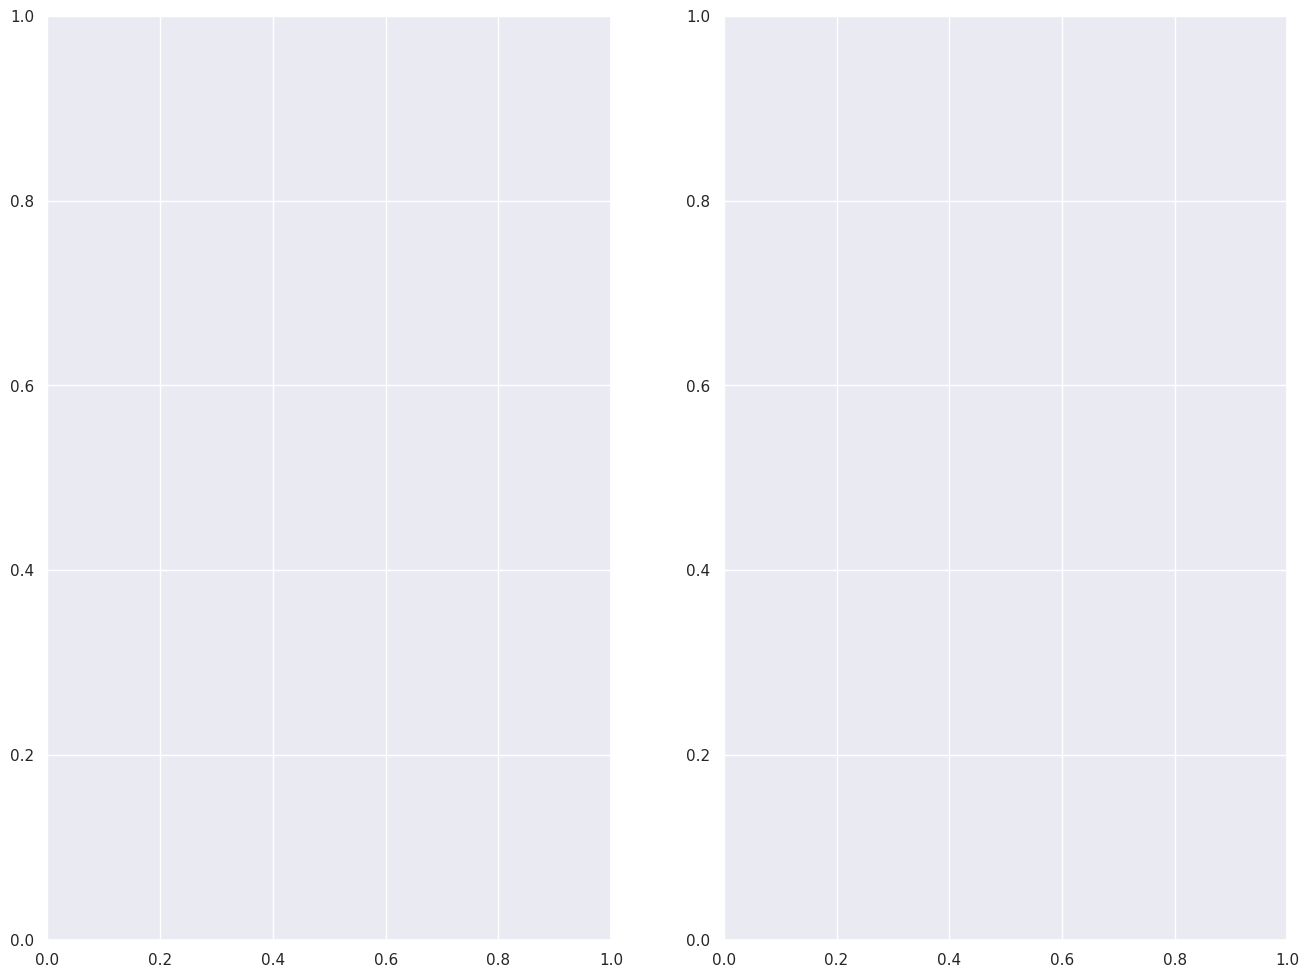

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
figure, axes = plt.subplots(1, 2, figsize=(16, 12))

Index([], dtype='int64')


<Axes: xlabel='PM2.5', ylabel='DEWP'>

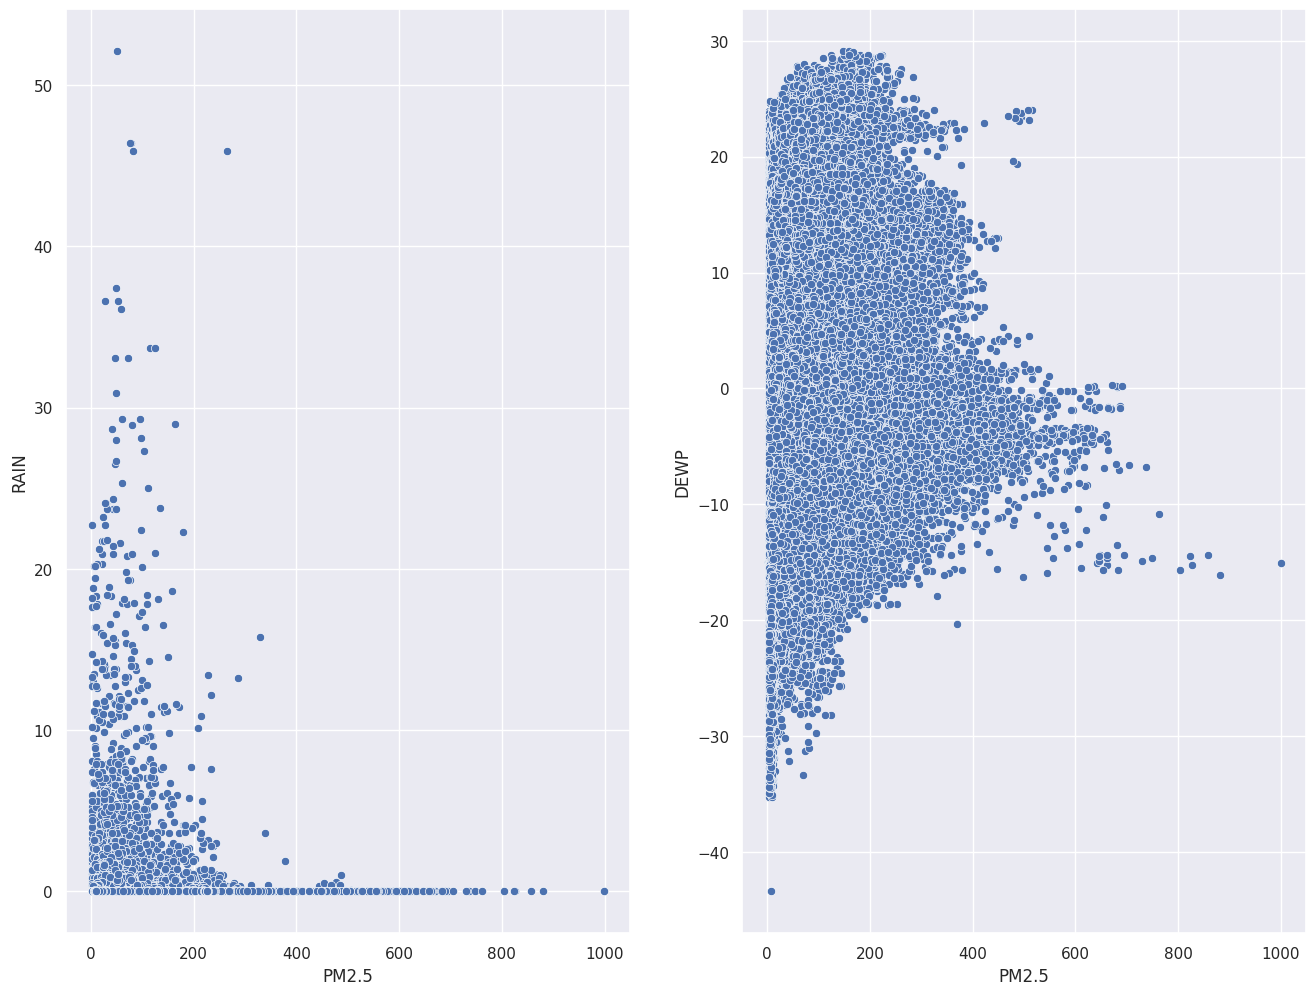

In [27]:

import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

#set seaborn plotting aesthetics as default
sns.set()
figure, axes = plt.subplots(1, 2, figsize=(16, 12))
full_df = full_df.reset_index(drop=True)
print(full_df.index[full_df.index.duplicated()])
#create scatterplot in each subplot
sns.scatterplot(data=full_df, x='PM2.5', y='RAIN', ax=axes[0])
sns.scatterplot(data=full_df, x='PM2.5', y='DEWP', ax=axes[1])
#print(full_df.index[full_df.index.duplicated()])

# **1. The Pollution Model (Predicting PM2.5)**
Pollution isn't just about other chemicals; it is heavily driven by weather. Wind "blows" pollution away, while certain temperatures "trap" it.

Target (y): PM2.5

Features (X): PM10, NO2, CO, WSPM (Wind Speed), and TEMP.

What to expect:

PM10 & CO: Will have positive coefficients (they usually rise
together).

WSPM (Wind Speed): Will likely have a negative coefficient (higher wind = lower pollution). This is a great way to track the "impact" of wind on air quality.


In [28]:
df_clean = full_df[['AQI','PM2.5', 'NO2', 'CO', 'WSPM', 'TEMP','RAIN','PRES','SO2','CO','DEWP','year','month','day','hour']].dropna()

print("WSM nulls:", df_clean['WSPM'].isna().sum())

WSM nulls: 0


In [29]:
## ----------------- Statistical Summary of Data set ------------------##
##full_df.head()
#full_df['year'].unique() ## all months

## yearly data based on months
#df_clean.groupby(['year', 'month','station'], as_index=True).first(2)
## some of the months are missing in some years

# ─── Statistical Summary ───────────────────────────────────────────
NUM_COLS = ["AQI","PM2.5","NO2","CO","TEMP","WSPM","PRES","DEWP","RAIN","SO2","O3","year","month","daya","hour"]
NUM_COLS = [c for c in NUM_COLS if c in df_clean.columns]

summary = df_clean[NUM_COLS].describe().T
summary["skewness"] = df_clean[NUM_COLS].skew().round(2)
summary["kurtosis"] = df_clean[NUM_COLS].kurt().round(2)
print("Statistical Summary of Numerical Variables:")
print(summary.round(2).to_string())

Statistical Summary of Numerical Variables:
          count     mean      std      min      25%     50%      75%      max  skewness  kurtosis
AQI    140256.0   142.99    84.89    14.00    69.00   147.0   186.00    500.0      0.86      0.77
PM2.5  140256.0    76.65    79.00     2.00    19.00    53.0   106.00    999.0      2.08      6.50
NO2    140256.0    42.24    32.89     1.03    17.00    34.0    60.00    258.0      1.23      1.72
CO     140256.0  1156.78  1056.85   100.00   500.00   900.0  1414.35  10000.0      2.68     11.02
CO     140256.0  1156.78  1056.85   100.00   500.00   900.0  1414.35  10000.0      2.68     11.02
TEMP   140256.0    13.39    11.51   -19.90     3.00    14.4    23.10     41.4     -0.11     -1.13
WSPM   140256.0     1.78     1.25     0.00     0.90     1.4     2.20     13.2      1.73      4.01
PRES   140256.0  1009.86    10.51   982.40  1001.40  1009.4  1018.00   1042.0      0.12     -0.81
DEWP   140256.0     2.21    13.86   -43.40    -9.30     2.7    14.90     2

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Create the log target
df_clean['log_PM25'] = np.log1p(df_clean['PM2.5'])

# 2. Define X and y (Ensure y is the LOG version)
X = df_clean[['NO2', 'CO', 'WSPM', 'TEMP']]
y = df_clean['log_PM25']

# 3. Split the data AFTER logging
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Fit and Predict
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. Evaluate (Both y_test and y_pred are now in the same 'Log Scale')
print(f"R2-score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_test-y_pred)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_test-y_pred)**2))
print("R2-score: %.2f" % r2_score(y_test,y_pred))


R2-score: 0.56
MAE: 0.58
Mean absolute error: 0.58
Residual sum of squares (MSE): 0.55
R2-score: 0.56


In [31]:
# Apply this before training
import numpy as np
df_clean['log_PM25'] = np.log1p(df_clean['PM2.5']) # log1p handles 0s safely
#df_clean['log_CO'] = np.log1p(df_clean['CO'])
#df_clean['log_NO2'] = np.log1p(df_clean['NO2'])
#df_clean['log_TEMP'] = np.log1p(df_clean['TEMP'])
#df_clean['log_WSPM'] = np.log1p(df_clean['WSPM'])
#

In [32]:
#X_train = X_train.fillna(X_train.mean())
#X=df_clean[['PM2.5']]
X=df_clean[['WSPM']]
X
#y=df_clean[['WSPM']]
y=df_clean[['log_PM25']]
y

,log_PM25
0,2.302585
1,1.609438
2,2.079442
3,1.386294
4,1.386294
...,...
140251,2.833213
140252,3.091042
140253,2.890372
140254,2.484907


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [34]:
# Checking the shape of the X_train, y_train and X_test and y_test
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(93971, 1)
(93971, 1)
(46285, 1)
(46285, 1)


In [35]:
print(X_train)

        WSPM
92006    2.1
116511   1.2
33336    1.2
72091    0.6
123746   6.2
...      ...
106482   1.2
27346    1.3
20684    3.4
63502    3.0
101471   0.8

[93971 rows x 1 columns]


In [36]:
print(y_train)

        log_PM25
92006   2.944439
116511  4.521789
33336   5.662960
72091   4.700480
123746  2.397895
...          ...
106482  5.252273
27346   5.337538
20684   4.343805
63502   3.828641
101471  4.204693

[93971 rows x 1 columns]


In [37]:
from sklearn import linear_model

regr=linear_model.LinearRegression()
regr.fit(X_train,y_train)

# The coefficients
print('Coefficients:', regr.coef_)
print('Intercept:', regr.intercept_)

Coefficients: [[-0.30954811]]
Intercept: [4.37927228]


In [38]:
from sklearn.metrics import r2_score
ypredict = regr.predict(X_test)

In [39]:
# Using the sklearn for error metric calculation:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, ypredict)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.8579382107448045


In [40]:
# Error metric calculation using Formula
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_test-ypredict)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_test-ypredict)**2))
print("R2-score: %.2f" % r2_score(y_test,ypredict))

Mean absolute error: 0.86
Residual sum of squares (MSE): 1.09
R2-score: 0.12


In [41]:
#['PM2.5', 'PM10', 'NO2', 'CO', 'WSPM', 'TEMP']]

In [42]:
#X=full_df[['AQI','PM2.5','NO2','SO2']]
X=df_clean[['NO2', 'CO', 'WSPM', 'TEMP']]  ## PM10 removed as it is derived from PM2.5 and has similar values as PM2.5. it always gives wrong results
#X=df_clean[['log_NO2', 'log_CO', 'log_WSPM', 'log_TEMP']]
X




,NO2,CO,CO,WSPM,TEMP
0,17.000000,300.000000,300.000000,5.7,-0.5
1,16.000000,300.000000,300.000000,3.9,-0.7
2,17.000000,300.000000,300.000000,5.3,-1.2
3,18.000000,1414.352003,1414.352003,4.9,-1.4
4,61.793197,200.000000,200.000000,3.2,-1.9
...,...,...,...,...,...
140251,19.000000,300.000000,300.000000,1.8,9.9
140252,24.000000,500.000000,500.000000,1.3,9.5
140253,39.000000,900.000000,900.000000,1.5,8.4
140254,32.000000,1400.000000,1400.000000,3.2,8.3


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [44]:
# importing module
from sklearn.linear_model import LinearRegression

# creating an object of LinearRegression class
LR = LinearRegression()
# fitting the training data
LR.fit(X_train,y_train)

LinearRegression()

In [45]:
y_pred =  LR.predict(X_test)
y_pred

array([[3.98072212],
       [3.27620286],
       [4.81977621],
       ...,
       [4.33988228],
       [3.42022923],
       [4.28589533]])

In [46]:
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_test-y_pred)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_test-y_pred)**2))
print("R2-score: %.2f" % r2_score(y_test,y_pred))

Mean absolute error: 0.58
Residual sum of squares (MSE): 0.55
R2-score: 0.56


# **2. The Weather Model (Predicting DEWP)**
R2 Score can be low because AQI doesn't "cause" the Dew Point. Instead, use the variables that physically dictate moisture.

Target (y): DEWP

Features (X): TEMP, PRES (Pressure), and RAIN.

What to expect:

TEMP: Will have a strong positive coefficient (warm air holds more moisture).

PRES: Will likely show a relationship with weather systems (low pressure often means higher humidity/dew point).

In [47]:
#import numpy as np
#df_clean['log_DEWP'] = np.log1p(df_clean['DEWP']) # log1p handles 0s safely

In [48]:
y2=df_clean[['DEWP']]
y2
X2=df_clean[['TEMP','PRES', 'RAIN']]
X2

,TEMP,PRES,RAIN
0,-0.5,1024.5,0.0
1,-0.7,1025.1,0.0
2,-1.2,1025.3,0.0
3,-1.4,1026.2,0.0
4,-1.9,1027.1,0.0
...,...,...,...
140251,9.9,1008.6,0.0
140252,9.5,1008.9,0.0
140253,8.4,1009.3,0.0
140254,8.3,1009.5,0.0


In [49]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.33)

In [50]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
####
print(X2_train.shape)
print(y2_train.shape)
print(X2_test.shape)
print(y2_test.shape)

(93971, 5)
(93971, 1)
(46285, 5)
(46285, 1)
(93971, 3)
(93971, 1)
(46285, 3)
(46285, 1)


In [51]:
# importing module
from sklearn.linear_model import LinearRegression

# creating an object of LinearRegression class
LR2 = LinearRegression()
# fitting the training data
LR2.fit(X2_train,y2_train)

LinearRegression()

In [52]:
y2_pred =  LR2.predict(X2_test)
y2_pred

array([[ 15.31354946],
       [ -8.53338789],
       [ 12.38377964],
       ...,
       [ 12.92217724],
       [-13.63479517],
       [  2.71114126]])

In [53]:
print("Mean absolute error: %.2f" % np.mean(np.absolute(y2_test-y2_pred)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y2_test-y2_pred)**2))
print("R2-score: %.2f" % r2_score(y2_test,y2_pred))

Mean absolute error: 6.30
Residual sum of squares (MSE): 58.80
R2-score: 0.69


In [54]:
full_df['year'].unique()

array([2013, 2014, 2015, 2016, 2017])

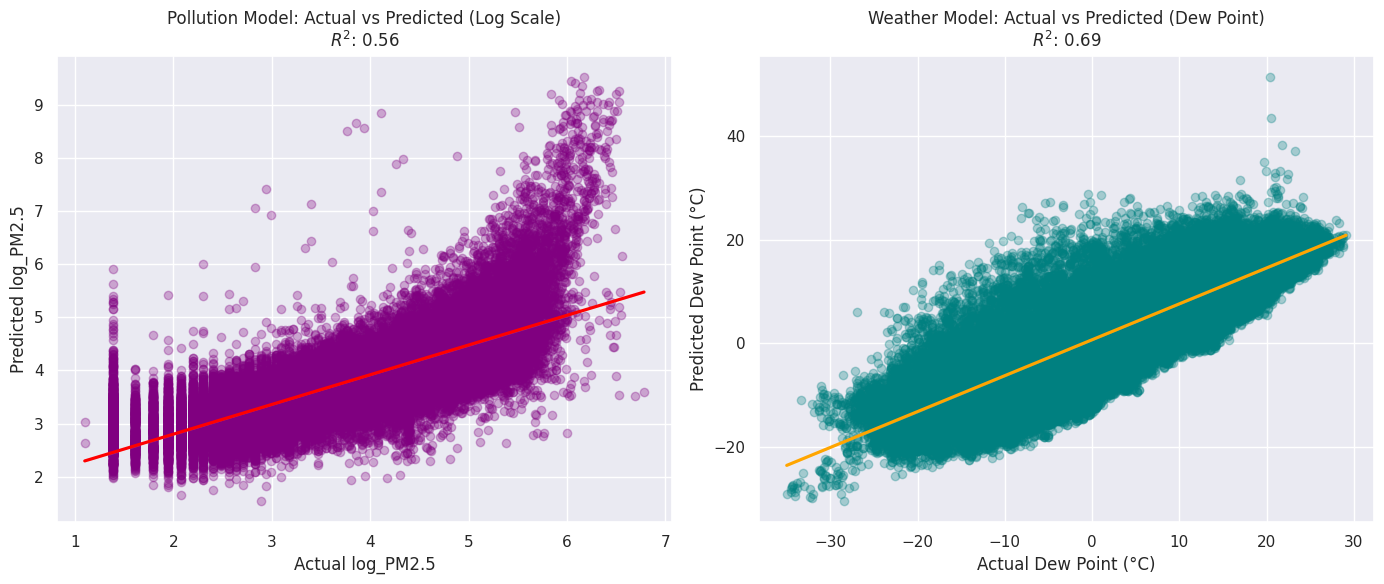

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# when trained 'model' (Pollution) and 'model2' (Weather)
# and have y_test, y_pred for both.

plt.figure(figsize=(14, 6))

# --- Graph 1: Pollution Model (log_PM2.5) ---
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'red'})
plt.title(f"Pollution Model: Actual vs Predicted (Log Scale)\n$R^2$: {r2_score(y_test, y_pred):.2f}")
plt.xlabel("Actual log_PM2.5")
plt.ylabel("Predicted log_PM2.5")

# --- Graph 2: Weather Model (DEWP) ---

plt.subplot(1, 2, 2)
sns.regplot(x=y2_test, y=y2_pred, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'orange'})
plt.title(f"Weather Model: Actual vs Predicted (Dew Point)\n$R^2$: {r2_score(y2_test, y2_pred):.2f}")
plt.xlabel("Actual Dew Point (°C)")
plt.ylabel("Predicted Dew Point (°C)")

plt.tight_layout()
plt.show()


# **KNN**

In [56]:
### Pollutants
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline

# --- 1. Scale your features (Mandatory for KNN) ---
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X) # Use the same X as before

#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Train KNN Regressor ---
# n_neighbors=5 is a good start; higher values 'smooth' the results
#knn_model = KNeighborsRegressor(n_neighbors=5)
#knn_model.fit(X_train, y_train)

# This 'Pipeline' ensures scaling happens correctly for every neighbor check
knn_pipe = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10))
knn_pipe.fit(X_train, y_train)


# --- 3. Predict and Evaluate ---
#y_pred_knn = knn_model.predict(X_test)
#print(f"KNN R2-score: {r2_score(y_test, y_pred_knn):.2f}")


print(f"Fixed KNN R2: {knn_pipe.score(X_test, y_test):.2f}")


Fixed KNN R2: 0.71


In [57]:
### Weather
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# --- 1. Scale your features (Mandatory for KNN) ---
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2) # Use the same X as before

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)

# --- 2. Train KNN Regressor ---
# n_neighbors=5 is a good start; higher values 'smooth' the results
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X2_train, y2_train)

# --- 3. Predict and Evaluate ---
y2_pred_knn = knn_model.predict(X2_test)
print(f"KNN R2-score: {r2_score(y2_test, y2_pred_knn):.2f}")


KNN R2-score: 0.69


# **SARIMAX**

In [58]:
df_clean.columns

Index(['AQI', 'PM2.5', 'NO2', 'CO', 'WSPM', 'TEMP', 'RAIN', 'PRES', 'SO2',
       'CO', 'DEWP', 'year', 'month', 'day', 'hour', 'log_PM25'],
      dtype='object')

In [65]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Create a proper datetime index
df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])
df_index = df_clean.set_index('datetime').sort_index()

# 2. Resample to DAILY frequency (Hourly is often too noisy for a first try)
# This smooths out the spikes and makes the 2018 prediction clearer
df_daily = df_index.resample('D').mean().dropna()

# 3. Define Target (y) and Weather Helpers (X)
y3 = df_daily['PM2.5']
X3 = df_daily[['TEMP', 'PRES', 'WSPM', 'DEWP']]


Optimization terminated successfully.
         Current function value: 4.188209
         Iterations: 350
         Function evaluations: 556


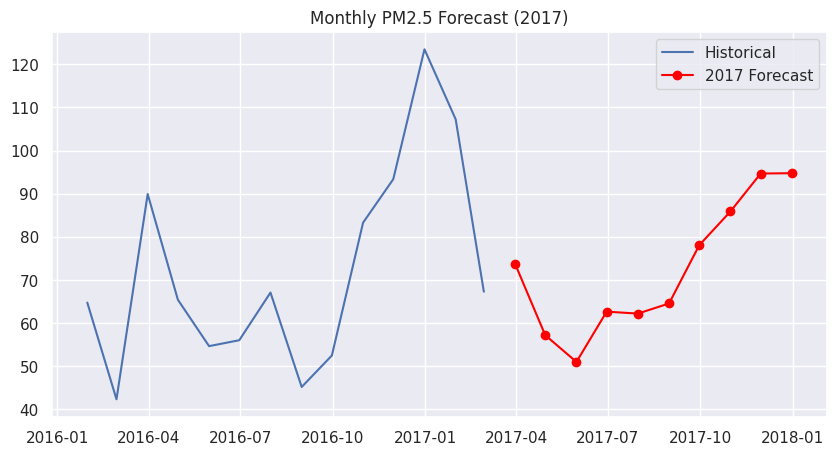

In [66]:
# 1. Ensure the weather profile is correctly aligned to months 1-12
weather_profile = X3.groupby(X3.index.month).mean()

# 2. Create the exogenous data for March (3) to Dec (12)
# We map the average weather to the specific months we are predicting
future_months = range(3, 13)
future_exog = weather_profile.loc[future_months]

# 3. If you want DAILY prediction, we need to expand those months to days
# For a quick check, let's just predict MONTHLY first to see if the shape is right
y_monthly = y3.resample('M').mean()
X_monthly = X3.resample('M').mean()

# 1. Simplify the model (Remove the complex seasonal math that is failing)
# We use order (1,0,0) which is simpler and less likely to "stall"
model_final = SARIMAX(y_monthly,
                      exog=X_monthly,
                      order=(1,0,0),             # Simplified trend
                      seasonal_order=(0,0,0,0),   # Let the Weather (X) handle the seasons
                      enforce_stationarity=False)

# 2. Fit with a different optimizer
results = model_final.fit(method='nm', maxiter=500) # 'nm' is more robust for small data

# 3. Predict the remaining 10 months of 2017
# Make sure future_exog has months 3 through 12
forecast = results.get_forecast(steps=10, exog=future_exog)
mean_forecast = forecast.predicted_mean

# 4. Plot to check the "U-Shape"
plt.figure(figsize=(10,5))
plt.plot(y_monthly['2016':], label='Historical')
plt.plot(mean_forecast, label='2017 Forecast', color='red', marker='o')
plt.title("Monthly PM2.5 Forecast (2017)")
plt.legend()
plt.show()


In [60]:
# Train-Test Split (2013-2016 for training, 2017 for validation)
train_y = y3['2014':'2016']
train_X = X3['2014':'2016']  # X3[:'2016']

# 1. Create 'Average Weather' to act as a placeholder for the missing months
# This takes the average weather for each day of the year from your 2014-2016 data
weather_profile = train_X.groupby([train_X.index.month, train_X.index.day]).mean()
# 2. Train on everything you have up to Feb 2017
model_ts = SARIMAX(train_y, exog=train_X, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model_ts.fit()

# Define the model
# order=(1,1,1) is a standard starting point for trend
# seasonal_order=(1,1,1,12) handles the 12-month yearly cycle
#model_ts = SARIMAX(train_y, exog=train_X, order=(1,1,1), seasonal_order=(1,1,1,12))
#results = model_ts.fit()

print(results.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                 1096
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -5539.227
Date:                            Sun, 26 Apr 2026   AIC                          11096.454
Time:                                    00:00:35   BIC                          11141.341
Sample:                                01-01-2014   HQIC                         11113.448
                                     - 12-31-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
TEMP          -1.1773      0.605     -1.947      0.052      -2.363       0.008
PRES          -1.9832      0.332   

In [61]:
df_clean.groupby('year')['month'].unique()

,month
year,
2013,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2014,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2015,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2016,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2017,"[1, 2]"


In [63]:

# 3. Create the 'Future Weather' for the next 300 days (March 2017 onwards)
# We just repeat the weather profile to fill 300 days
future_exog = pd.concat([weather_profile] * 2).iloc[59:359]



# 4. Predict
forecast = results.get_forecast(steps=300, exog=future_exog)
mean_forecast = forecast.predicted_mean


# 5. Plot the result
plt.figure(figsize=(12,6))
plt.plot(y3['2016':], label='Historical Data (Ends Feb 2017)')
plt.plot(mean_forecast, label='Predicted Remaining 2017', color='red', linestyle='--')
plt.title("Filling the Gap: PM2.5 Forecast for March-Dec 2017")
plt.legend()
plt.show()





ValueError: Provided exogenous values are not of the appropriate shape. Required (300, 4), got (0, 4).